#Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score )

import shap

Configurations

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
sns.set_theme(style='darkgrid', palette='viridis')

plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 8,
    'ytick.labelsize':8
})

VIBRANT_COLORS = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6A4C93', '#1982C4']

RANDOM_STATE = 42
TARGET_COL = "Rent_BDT"

USE_SERVICE_CHARGE = False
N_ITER_SEARCH = 20

#Data Load

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/Dhaka City Flat Rent/flat rent prices.csv')
df.head()

,Listing_ID,Location,Property_Type,Area_sqft,Bedrooms,Bathrooms,Floor,Balcony,Gas,Parking,Rent_BDT,Service_Charge_BDT,Listing Date
0,DHK0001,Bashaboo,Apartment,1180.000,3,2,NaN,2,N,Y,"16,500",3500,19/08/2026
1,DHK0002,East Bashaboo,Apartment,1200.000,3,3,NaN,3,N,Y,"17,500",3500,21/08/2026
2,DHK0003,Rajarbagh Kalibari,House,NaN,1,1,5.000,1,N,N,"6,000",NaN,25/08/2026
3,DHK0004,North Nondipara,Apartment,1195.000,3,3,9.000,3,N,NaN,"14,000",3500,24/08/2026
4,DHK0005,Banasree,Apartment,1200.000,3,3,5.000,NaN,N,NaN,"18,000",2000,24/08/2026


In [ ]:
df.shape

(103, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Listing_ID          103 non-null    object 
 1   Location            103 non-null    object 
 2   Property_Type       100 non-null    object 
 3   Area_sqft           56 non-null     float64
 4   Bedrooms            103 non-null    int64  
 5   Bathrooms           103 non-null    object 
 6   Floor               84 non-null     float64
 7   Balcony             92 non-null     object 
 8   Gas                 102 non-null    object 
 9   Parking             82 non-null     object 
 10  Rent_BDT            102 non-null    object 
 11  Service_Charge_BDT  84 non-null     object 
 12  Listing Date        103 non-null    object 
dtypes: float64(2), int64(1), object(10)
memory usage: 10.6+ KB


In [ ]:
df.columns

Index(['Listing_ID', 'Location', 'Property_Type', 'Area_sqft', 'Bedrooms',
       'Bathrooms', 'Floor', 'Balcony', 'Gas', 'Parking', 'Rent_BDT',
       'Service_Charge_BDT', 'Listing Date'],
      dtype='object')

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print('Numerical Columns:', num_cols)
print('Categorical Columns:', cat_cols)

Numerical Columns: ['Area_sqft', 'Bedrooms', 'Floor']
Categorical Columns: ['Listing_ID', 'Location', 'Property_Type', 'Bathrooms', 'Balcony', 'Gas', 'Parking', 'Rent_BDT', 'Service_Charge_BDT', 'Listing Date']


In [ ]:
#missing values analysis
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Listing_ID             0
Location               0
Property_Type          3
Area_sqft             47
Bedrooms               0
Bathrooms              0
Floor                 19
Balcony               11
Gas                    1
Parking               21
Rent_BDT               1
Service_Charge_BDT    19
Listing Date           0
dtype: int64


check presence of encoded missing values

In [ ]:
for col in df.columns:
  print(df[col].value_counts().head(20))

Listing_ID
DHK0001    1
DHK0002    1
DHK0003    1
DHK0004    1
DHK0005    1
DHK0006    1
DHK0007    1
DHK0008    1
DHK0009    1
DHK0010    1
DHK0011    1
DHK0012    1
DHK0013    1
DHK0014    1
DHK0015    1
DHK0016    1
DHK0017    1
DHK0018    1
DHK0019    1
DHK0020    1
Name: count, dtype: int64
Location
Banasree              16
Khilgaon              15
Mugda                  9
Kodomtola              7
Aftabnagar             6
Merul Badda            6
Rajarbagh Kalibari     5
Baganbari              5
Malibagh               5
North Nondipara        4
Sabujbagh              4
Khalpar                3
Bashaboo               3
Uttara                 3
South Mugda            2
Manda                  2
Mohammadpur            2
East Bashaboo          1
North Bashaboo         1
South Manda            1
Name: count, dtype: int64
Property_Type
Apartment    54
House        27
Bachelor     15
Sublet        4
Name: count, dtype: int64
Area_sqft
1200.000    12
800.000      6
1300.000     5
900.000  

In [ ]:
duplicat_mask = df.duplicated()
num_duplicates = duplicat_mask.sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


descriptive state

In [ ]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Area_sqft,56.000,1013.527,380.640,40.260,852.500,1195.000,1204.500,1500.000
Bedrooms,103.000,2.165,0.876,1.000,1.000,2.000,3.000,4.000
Floor,84.000,4.381,2.139,1.000,3.000,4.000,5.250,9.000


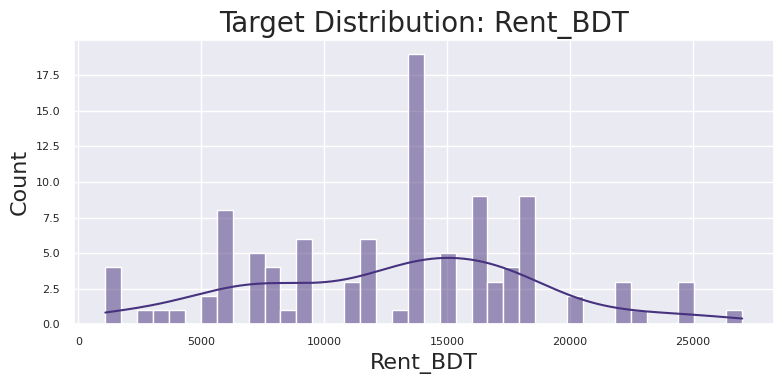

In [ ]:
# target column distribution
rent_numeric = pd.to_numeric(
    df[TARGET_COL].astype(str).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)

plt.figure(figsize=(8, 4))
sns.histplot(rent_numeric.dropna(), bins=40, kde=True)
plt.title("Target Distribution: Rent_BDT")
plt.xlabel("Rent_BDT")
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

#Data Cleaning

In [ ]:
text_cols = ['Location', 'Property_Type', 'Bathrooms', 'Balcony', 'Gas', 'Parking']
for c in text_cols:
    df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan})

In [ ]:
df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL].astype(str).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)
rows_before = len(df)
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
print(f"Dropped {rows_before - len(df)} row(s) with missing {TARGET_COL}. Remaining rows: {len(df)}")

Dropped 1 row(s) with missing Rent_BDT. Remaining rows: 102


In [ ]:
# Service_Charge_BDT: 'N' -> 0 (no service charge), 'Y' -> 1 (has service charge)
sc = (
    df['Service_Charge_BDT'].astype(str)
    .str.replace(',', '', regex=False).str.strip()
    .replace({'N': '0', 'Y': '1', 'nan': np.nan})
)
df['Service_Charge_BDT'] = pd.to_numeric(sc, errors='coerce')

# Balcony: 'N' -> 0 (no balcony), 'C' -> missing ("common balcony")
df['Balcony'] = pd.to_numeric(df['Balcony'].replace({'N': '0', 'C': np.nan}), errors='coerce')

# Gas: Yes/No -> 1/0
df['Gas'] = df['Gas'].map({'Y': 1, 'N': 0})

# Parking / Property_Type / Bathrooms: keep missingness as an explicit "Unknown" category
df['Parking'] = df['Parking'].fillna('Unknown')
df['Property_Type'] = df['Property_Type'].fillna('Unknown')
df['Bathrooms'] = df['Bathrooms'].fillna('Unknown')

print("Remaining missing values after cleaning:")
print(df.isnull().sum())

Remaining missing values after cleaning:
Listing_ID             0
Location               0
Property_Type          0
Area_sqft             46
Bedrooms               0
Bathrooms              0
Floor                 19
Balcony               12
Gas                    1
Parking                0
Rent_BDT               0
Service_Charge_BDT    19
Listing Date           0
dtype: int64


#Relationships between Features and Rent

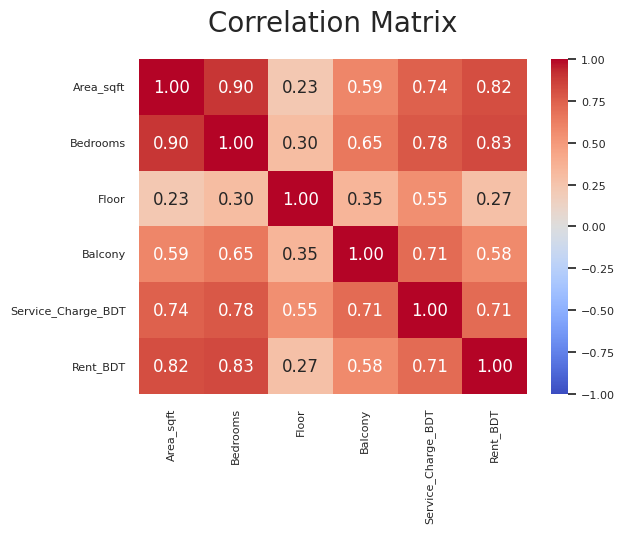

In [ ]:
numeric_eda_cols = ['Area_sqft', 'Bedrooms', 'Floor', 'Balcony', 'Service_Charge_BDT', TARGET_COL]
corr = df[numeric_eda_cols].corr()

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix', pad=20) # Numeric Features vs Rent
plt.savefig("correlation_matrix.png", dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
print("Correlation with", TARGET_COL, ":")
print(corr[TARGET_COL].sort_values(ascending=False))

Correlation with Rent_BDT :
Rent_BDT             1.000
Bedrooms             0.830
Area_sqft            0.820
Service_Charge_BDT   0.710
Balcony              0.577
Floor                0.275
Name: Rent_BDT, dtype: float64


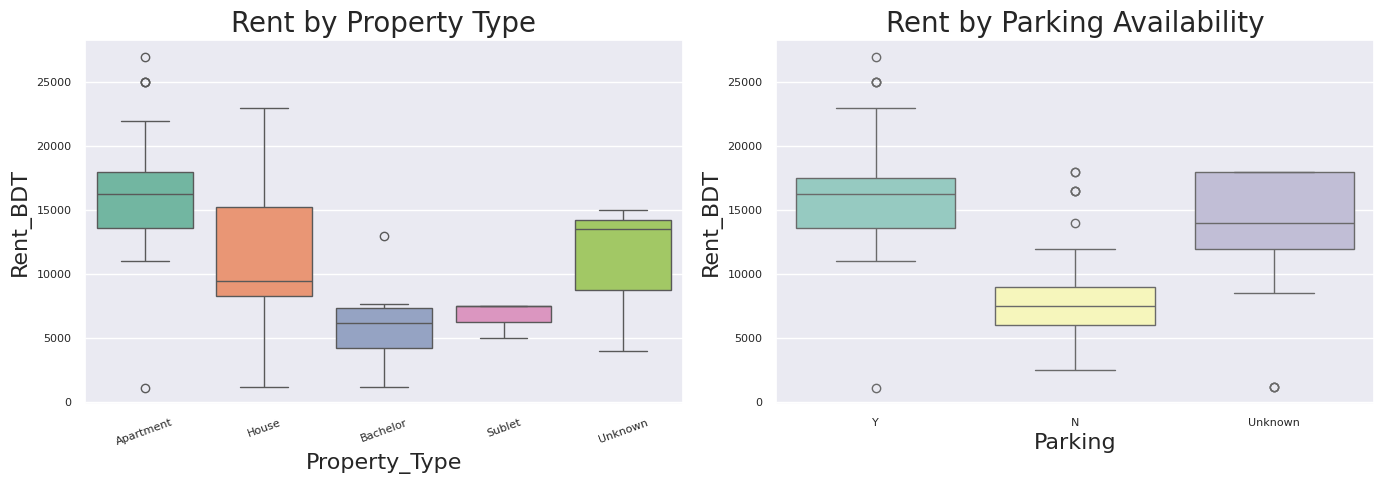

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Property_Type', y=TARGET_COL, hue='Property_Type',
            palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Rent by Property Type')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='Parking', y=TARGET_COL, hue='Parking',
            palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Rent by Parking Availability')
plt.tight_layout()
plt.show()

#Feature Set and Train/Test Split

In [ ]:
numeric_features = ['Area_sqft', 'Bedrooms', 'Floor', 'Balcony']
if USE_SERVICE_CHARGE:
    numeric_features.append('Service_Charge_BDT')
binary_features = ['Gas']
categorical_features = ['Location', 'Property_Type', 'Bathrooms', 'Parking']

feature_cols = numeric_features + binary_features + categorical_features
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Features used:", feature_cols)

Train: (81, 9), Test: (21, 9)
Features used: ['Area_sqft', 'Bedrooms', 'Floor', 'Balcony', 'Gas', 'Location', 'Property_Type', 'Bathrooms', 'Parking']


#Preprocessing Pipeline

In [ ]:
def build_preprocessor(num_feats, bin_feats, cat_feats):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler())
    ])

    binary_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=3))
    ])

    return ColumnTransformer(transformers=[
        ('num', numeric_transformer, num_feats),
        ('bin', binary_transformer, bin_feats),
        ('cat', categorical_transformer, cat_feats)
    ])

preprocessor = build_preprocessor(numeric_features, binary_features, categorical_features)

In [ ]:
ablation_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
base_num = [f for f in numeric_features if f != 'Service_Charge_BDT']

abl_rows = []
for label, num_f in [('Without Service_Charge_BDT', base_num),
                     ('With Service_Charge_BDT', base_num + ['Service_Charge_BDT'])]:
    cols = num_f + binary_features + categorical_features
    pipe = Pipeline(steps=[
        ('preprocessor', build_preprocessor(num_f, binary_features, categorical_features)),
        ('model', RandomForestRegressor(n_estimators=200, max_depth=6,
                                        min_samples_leaf=2, random_state=RANDOM_STATE))
    ])
    res = cross_validate(pipe, df.loc[X_train.index, cols], y_train, cv=ablation_cv,
                         scoring={'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'}, n_jobs=-1)
    abl_rows.append({'Feature set': label,
                     'CV RMSE (mean)': -res['test_RMSE'].mean(),
                     'CV RMSE (std)': res['test_RMSE'].std(),
                     'CV R2 (mean)': res['test_R2'].mean()})

pd.DataFrame(abl_rows).set_index('Feature set').round(3)

,CV RMSE (mean),CV RMSE (std),CV R2 (mean)
Feature set,,,
Without Service_Charge_BDT,2895.220,641.171,0.723
With Service_Charge_BDT,2863.717,673.571,0.730


#Models and Hyperparameter Tuning

In [ ]:
def make_pipe(model):
    return Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

base_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, verbosity=0)
}

param_distributions = {
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [3, 4, 6, 8, None],
        'model__min_samples_leaf': [1, 2, 3, 5],
        'model__max_features': [0.5, 0.75, 1.0],
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [2, 3, 4, 5],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        'model__min_child_weight': [1, 2, 3, 5],
        'model__reg_lambda': [0.1, 1, 5, 10],
    },
}

inner_cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

estimators = {}
for name, model in base_models.items():
    pipe = make_pipe(model)
    if name in param_distributions:
        estimators[name] = RandomizedSearchCV(
            pipe, param_distributions[name], n_iter=N_ITER_SEARCH,
            scoring='neg_root_mean_squared_error', cv=inner_cv,
            random_state=RANDOM_STATE, n_jobs=-1, refit=True
        )
    else:
        estimators[name] = pipe

#Model Comparison: Nested Cross-Validated MAE, RMSE, R²


In [ ]:
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

cv_rows = []
for name, est in estimators.items():
    cv_res = cross_validate(est, X_train, y_train, cv=outer_cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        'Model': name,
        'CV MAE (mean)': -cv_res['test_MAE'].mean(),
        'CV MAE (std)': cv_res['test_MAE'].std(),
        'CV RMSE (mean)': -cv_res['test_RMSE'].mean(),
        'CV RMSE (std)': cv_res['test_RMSE'].std(),
        'CV R2 (mean)': cv_res['test_R2'].mean(),
        'CV R2 (std)': cv_res['test_R2'].std(),
    })

cv_results_df = pd.DataFrame(cv_rows).set_index('Model')
cv_results_df.round(3)

,CV MAE (mean),CV MAE (std),CV RMSE (mean),CV RMSE (std),CV R2 (mean),CV R2 (std)
Model,,,,,,
Linear Regression,2823.723,886.445,3764.050,1163.118,0.511,0.256
Random Forest,2059.292,463.312,2899.090,652.446,0.718,0.120
XGBoost,2025.047,467.494,3014.135,684.530,0.697,0.116


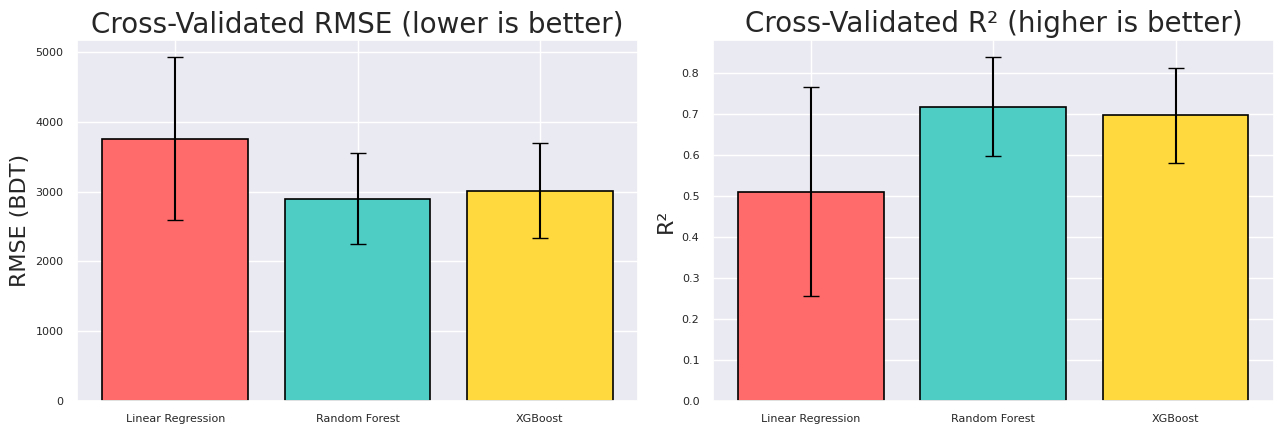

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(
    cv_results_df.index,
    cv_results_df['CV RMSE (mean)'],
    yerr=cv_results_df['CV RMSE (std)'],
    capsize=6,
    color=VIBRANT_COLORS[:len(cv_results_df)],
    edgecolor='black',
    linewidth=1.2
)
axes[0].set_title('Cross-Validated RMSE (lower is better)')
axes[0].set_ylabel('RMSE (BDT)')

axes[1].bar(
    cv_results_df.index,
    cv_results_df['CV R2 (mean)'],
    yerr=cv_results_df['CV R2 (std)'],
    capsize=6,
    color=VIBRANT_COLORS[:len(cv_results_df)],
    edgecolor='black',
    linewidth=1.2
)
axes[1].set_title('Cross-Validated R² (higher is better)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('R²')

plt.tight_layout()

plt.savefig(
    "cross_validation_results_combined.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

#Holdout Test Set Performance

In [ ]:
test_rows = []
fitted_models = {}
for name, est in estimators.items():
    est.fit(X_train, y_train)          # tuning uses the training set only
    fitted_models[name] = est
    if hasattr(est, 'best_params_'):
        print(f"{name} best hyperparameters: {est.best_params_}")
    preds = est.predict(X_test)
    test_rows.append({
        'Model': name,
        'Test MAE': mean_absolute_error(y_test, preds),
        'Test RMSE': root_mean_squared_error(y_test, preds),
        'Test R2': r2_score(y_test, preds),
    })

test_results_df = pd.DataFrame(test_rows).set_index('Model')

results_df = cv_results_df.join(test_results_df)
results_df.round(3)

Random Forest best hyperparameters: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
XGBoost best hyperparameters: {'model__subsample': 0.8, 'model__reg_lambda': 10, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


,CV MAE (mean),CV MAE (std),CV RMSE (mean),CV RMSE (std),CV R2 (mean),CV R2 (std),Test MAE,Test RMSE,Test R2
Model,,,,,,,,,
Linear Regression,2823.723,886.445,3764.050,1163.118,0.511,0.256,1870.670,2393.763,0.773
Random Forest,2059.292,463.312,2899.090,652.446,0.718,0.120,1450.296,1883.288,0.859
XGBoost,2025.047,467.494,3014.135,684.530,0.697,0.116,1623.287,2437.423,0.764


#Selecting the best model

In [ ]:
best_model_name = cv_results_df['CV RMSE (mean)'].idxmin()
print(f"Best model by mean CV RMSE: {best_model_name}")

best_est = fitted_models[best_model_name]
best_pipe = best_est.best_estimator_ if hasattr(best_est, 'best_estimator_') else best_est
best_preds = best_pipe.predict(X_test)

print(f"\n{best_model_name} — held-out test performance:")
print(f"  MAE:  {mean_absolute_error(y_test, best_preds):,.0f} BDT")
print(f"  RMSE: {root_mean_squared_error(y_test, best_preds):,.0f} BDT")
print(f"  R2:   {r2_score(y_test, best_preds):.3f}")

Best model by mean CV RMSE: Random Forest

Random Forest — held-out test performance:
  MAE:  1,450 BDT
  RMSE: 1,883 BDT
  R2:   0.859


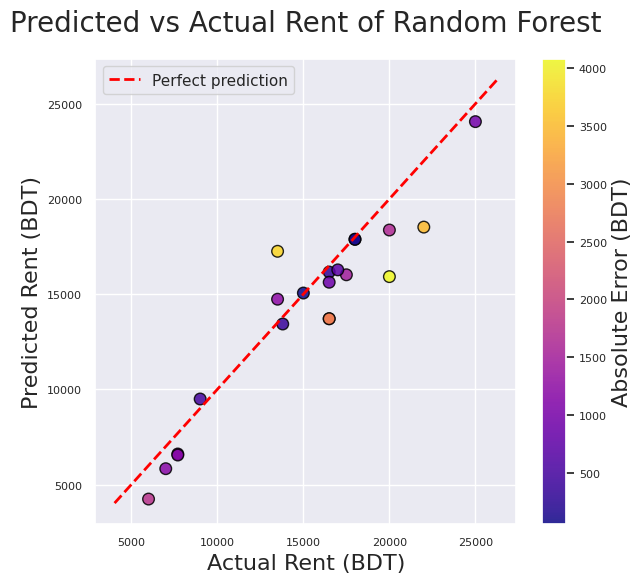

In [ ]:
plt.figure(figsize=(6.5, 6))
errors = np.abs(y_test.values - best_preds)
sc = plt.scatter(y_test, best_preds, c=errors, cmap='plasma', alpha=0.85, edgecolor='k', s=70)

plt.colorbar(sc, label='Absolute Error (BDT)')
lims = [min(y_test.min(), best_preds.min()) * 0.95, max(y_test.max(), best_preds.max()) * 1.05]

plt.plot(lims, lims, 'r--', label='Perfect prediction', linewidth=2)

plt.xlabel('Actual Rent (BDT)')
plt.ylabel('Predicted Rent (BDT)')
plt.title(f'Predicted vs Actual Rent of {best_model_name}', pad=20) # Test Set
plt.legend()
plt.tight_layout()

plt.savefig("predicted_vs_actual_rent.png", dpi=600, bbox_inches="tight")
plt.show()

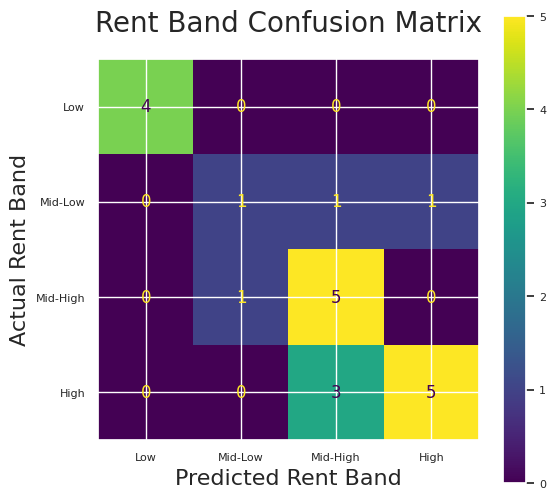

Rent-band classification accuracy: 71.4%


In [ ]:
band_labels = ['Low', 'Mid-Low', 'Mid-High', 'High']
_, bin_edges = pd.qcut(y_train, q=4, labels=band_labels, retbins=True)
bin_edges = bin_edges.copy()
bin_edges[0], bin_edges[-1] = -np.inf, np.inf  # so any test value outside train's range still gets a band

y_test_band = pd.cut(y_test, bins=bin_edges, labels=band_labels)
pred_band = pd.cut(best_preds, bins=bin_edges, labels=band_labels)

cm = confusion_matrix(y_test_band, pred_band, labels=band_labels)

fig, ax = plt.subplots(figsize=(6, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=band_labels)
disp.plot(ax=ax, cmap='viridis', colorbar=True, values_format='d')
ax.set_title(f'Rent Band Confusion Matrix', pad=20) #Best model test set
ax.set_xlabel('Predicted Rent Band')
ax.set_ylabel('Actual Rent Band')
plt.tight_layout()
plt.savefig("best_model_confusion_matrix.png", dpi=600, bbox_inches="tight")
plt.show()

band_accuracy = (y_test_band.astype(str) == pred_band.astype(str)).mean()
print(f"Rent-band classification accuracy: {band_accuracy:.1%}")

#SHAP: Which Features Drive Predicted Rent?

In [ ]:
explainer = shap.TreeExplainer(best_pipe.named_steps['model'])

feat_names_raw = best_pipe.named_steps['preprocessor'].get_feature_names_out()
feat_names = [f.split('__', 1)[-1] for f in feat_names_raw]

X_test_trans = best_pipe.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_trans, 'toarray'):
    X_test_trans = X_test_trans.toarray()

shap_values = explainer(X_test_trans)
shap_values.feature_names = feat_names

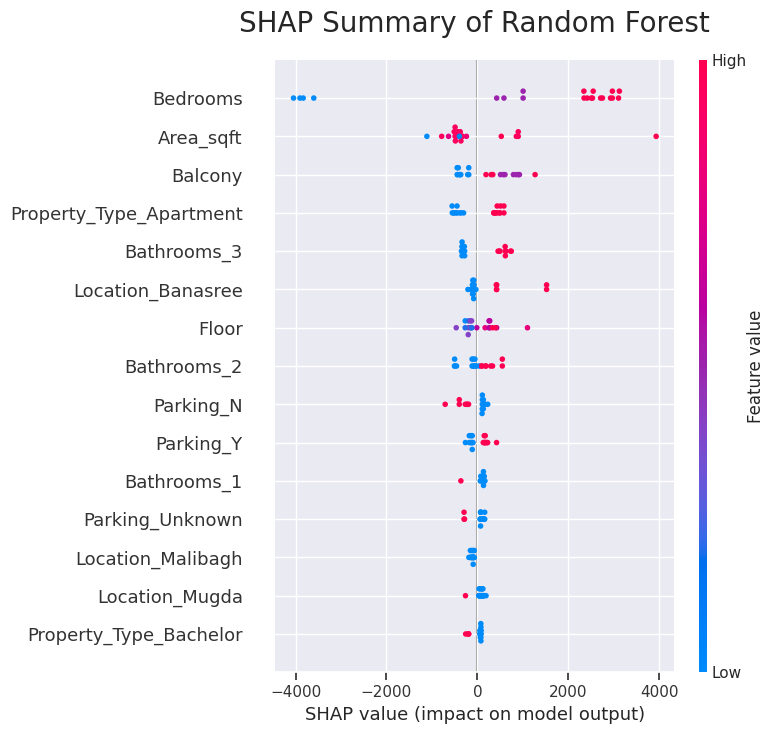

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_test_trans, feature_names=feat_names, max_display=15, show=False)
plt.title(f'SHAP Summary of {best_model_name}', pad=20)

plt.tight_layout()

plt.savefig("best_model_shap_summary.png", dpi=600, bbox_inches="tight")
plt.show()

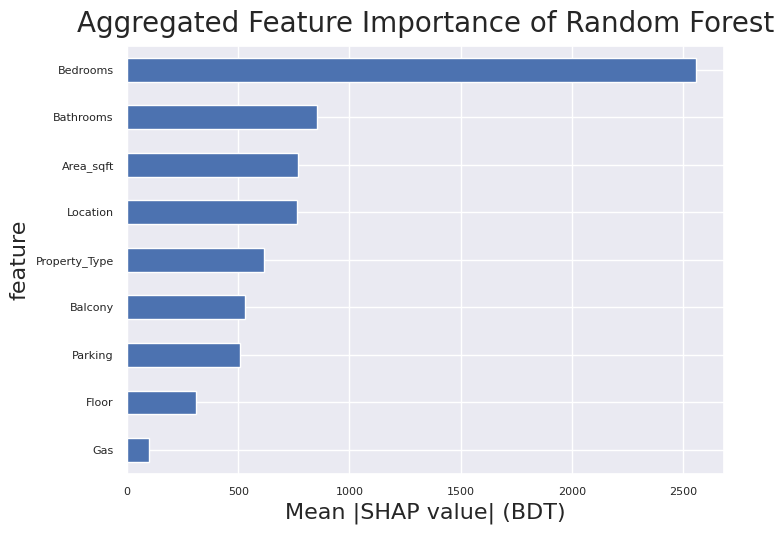

In [ ]:
def map_to_original(name):
    if name.startswith('missingindicator_'):
        return name[len('missingindicator_'):]
    for cat in categorical_features:
        if name.startswith(cat + '_'):
            return cat
    return name

groups = [map_to_original(f) for f in feat_names]
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

agg_importance = (
    pd.DataFrame({'feature': groups, 'mean_abs_shap': mean_abs_shap})
    .groupby('feature')['mean_abs_shap'].sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7.5, 5.5))

agg_importance.sort_values().plot(kind='barh', color='#4c72b0')

plt.xlabel('Mean |SHAP value| (BDT)')
plt.title(f'Aggregated Feature Importance of {best_model_name}', pad=10)

plt.savefig("aggregated_feature_importance.png", dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
agg_importance

,mean_abs_shap
feature,
Bedrooms,2556.542
Bathrooms,855.735
Area_sqft,770.323
Location,763.184
Property_Type,614.128
Balcony,530.981
Parking,508.326
Floor,311.247
Gas,97.102


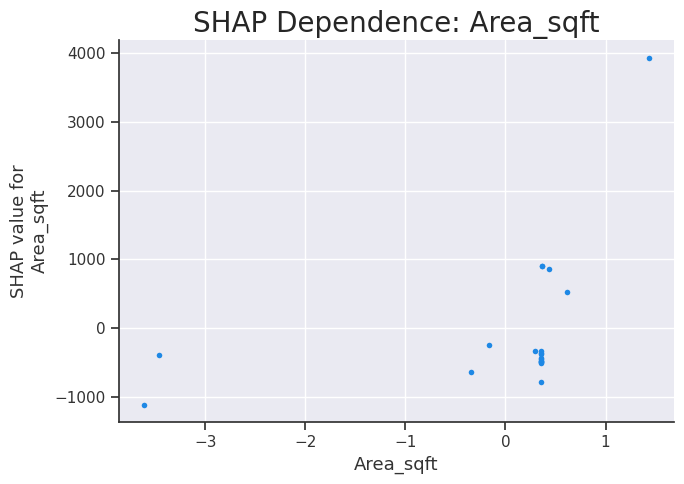

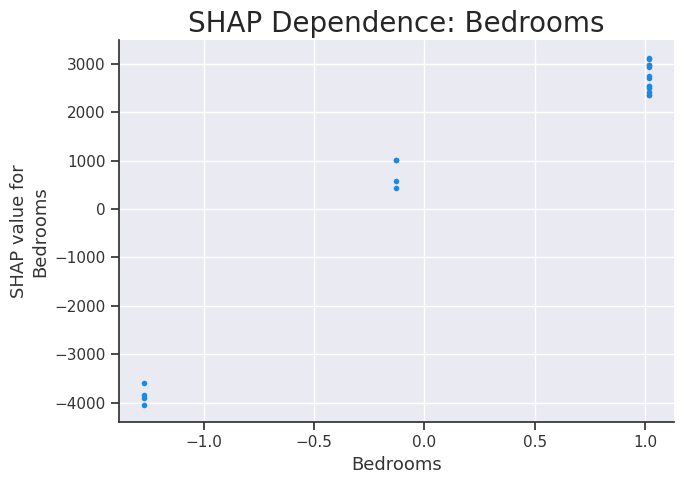

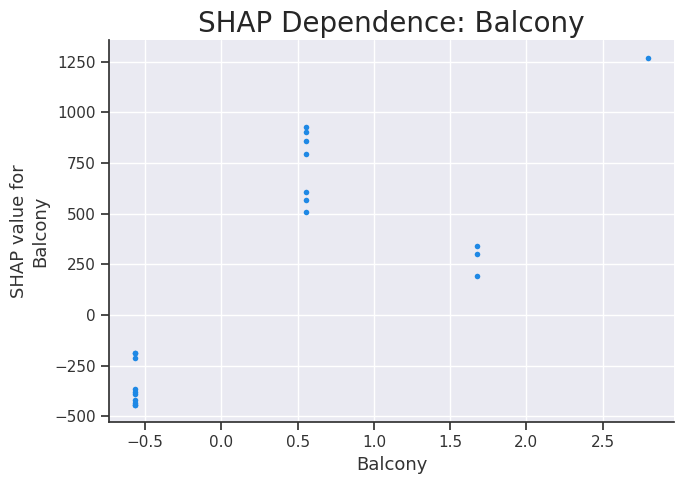

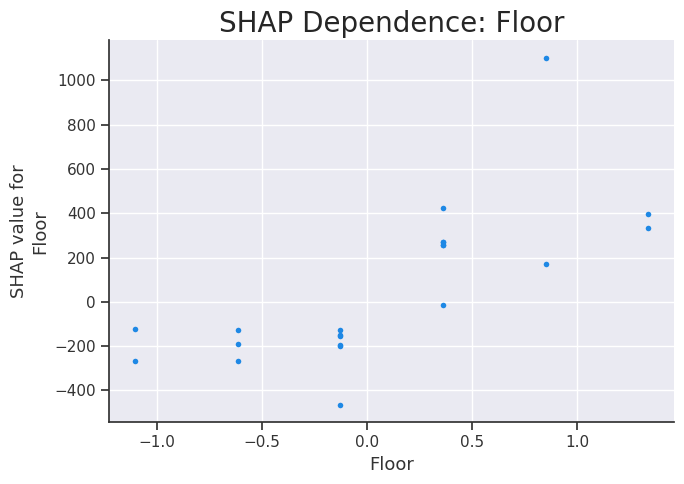

In [ ]:
dep_features = ['Area_sqft', 'Bedrooms', 'Balcony',
                'Service_Charge_BDT' if USE_SERVICE_CHARGE else 'Floor']
X_test_trans_df = pd.DataFrame(X_test_trans, columns=feat_names)

for feat in dep_features:

    fig, ax = plt.subplots(figsize=(7, 5))

    shap.dependence_plot(
        feat,
        shap_values.values,
        X_test_trans_df,
        interaction_index=None,
        ax=ax,
        show=False
    )

    ax.set_title(f'SHAP Dependence: {feat}')

    fig.tight_layout()

    safe_feat = feat.replace('/', '_')
    fig.savefig(
        f"shap_dependency_{safe_feat}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


In [ ]:
files.download("shap_dependency_Area_sqft.png")
files.download("shap_dependency_Bedrooms.png")
files.download("shap_dependency_Balcony.png")
files.download("shap_dependency_Floor.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

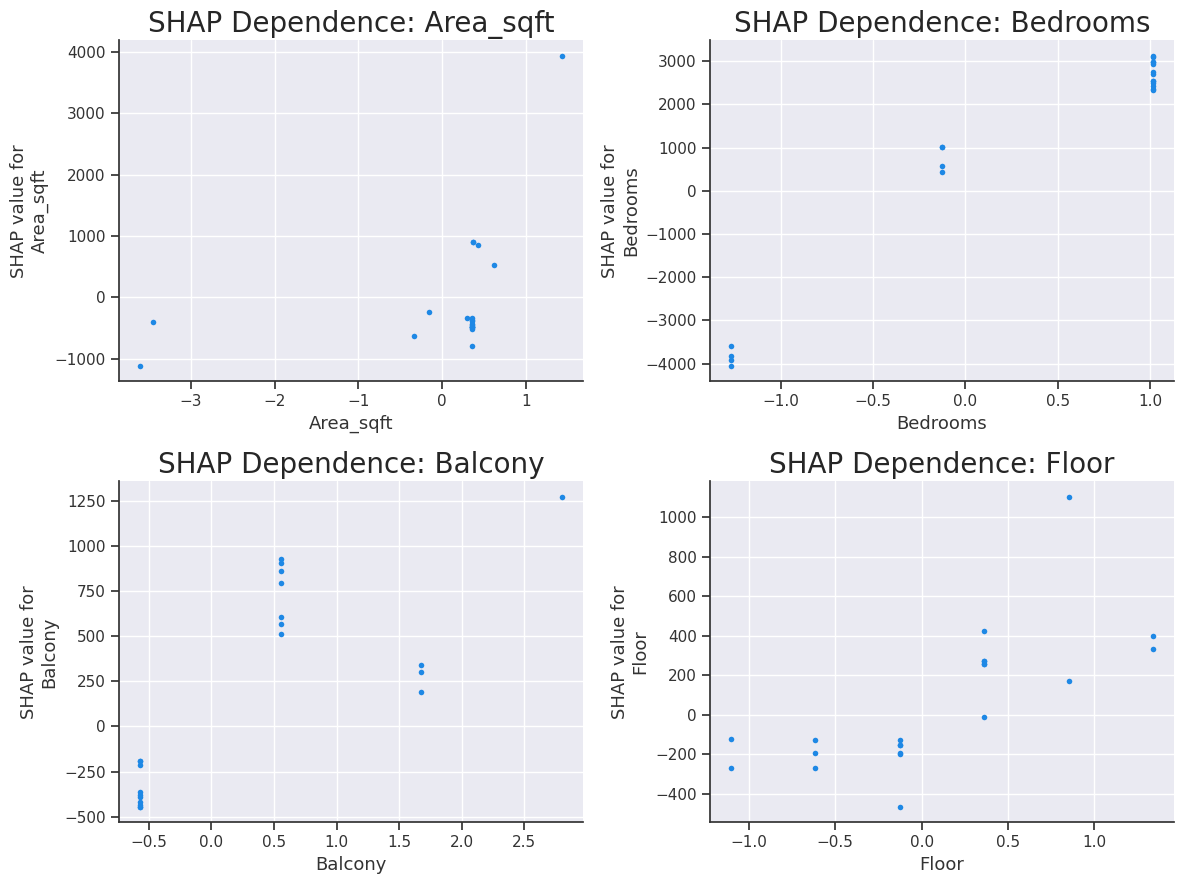

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feat in zip(axes.ravel(), dep_features):

    shap.dependence_plot(
        feat,
        shap_values.values,
        X_test_trans_df,
        interaction_index=None,
        ax=ax,
        show=False
    )

    ax.set_title(f'SHAP Dependence: {feat}')

fig.tight_layout()

fig.savefig("shap_dependence_all_features.png", dpi=600, bbox_inches="tight")

plt.show()
plt.close(fig)

In [ ]:
files.download("correlation_matrix.png")
files.download("cross_validation_results_combined.png")
files.download("best_model_confusion_matrix.png")
files.download("predicted_vs_actual_rent.png")
files.download("best_model_shap_summary.png")
files.download("aggregated_feature_importance.png")
files.download("shap_dependence_all_features.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>